In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
power = pd.read_csv("PGCB_date_power_demand.csv")
weather = pd.read_csv("weather_data.csv")
economic = pd.read_csv("economic_full_1.csv")

In [3]:
power.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [4]:
power.info()

<class 'pandas.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              92650 non-null  str    
 1   generation_mw         92650 non-null  float64
 2   demand_mw             92650 non-null  int64  
 3   load_shedding         92650 non-null  int64  
 4   gas                   92650 non-null  int64  
 5   liquid_fuel           92650 non-null  int64  
 6   coal                  92650 non-null  int64  
 7   hydro                 92650 non-null  int64  
 8   solar                 70517 non-null  float64
 9   wind                  18676 non-null  float64
 10  india_bheramara_hvdc  92650 non-null  int64  
 11  india_tripura         92650 non-null  int64  
 12  india_adani           7338 non-null   float64
 13  nepal                 5351 non-null   float64
 14  remarks               6393 non-null   str    
dtypes: float64(5), int64(8), str(2

In [5]:
print(power.columns)

Index(['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks'],
      dtype='str')


In [6]:

k = power.isna().sum()
k[k!=0]

solar          22133
wind           73974
india_adani    85312
nepal          87299
remarks        86257
dtype: int64

In [7]:

k = weather.isna().sum()
k[k!=0]

Series([], dtype: int64)

In [8]:

k = economic.isna().sum()
print(k[k!=0])

1960    1340
1961    1299
1962    1306
1963    1306
1964    1306
        ... 
2021     510
2022     461
2023     648
2024     843
2025    1447
Length: 66, dtype: int64


In [9]:
economic['Indicator Name'].to_list()

['Intentional homicides, male (per 100,000 male)',
 'Battle-related deaths (number of people)',
 'Voice and Accountability: Percentile Rank',
 'Transport services (% of commercial service exports)',
 'Computer, communications and other services (% of commercial service exports)',
 'Merchandise exports by the reporting economy, residual (% of total merchandise exports)',
 'Merchandise exports to low- and middle-income economies in Latin America & the Caribbean (% of total merchandise exports)',
 'Merchandise exports to high-income economies (% of total merchandise exports)',
 'Manufactures exports (% of merchandise exports)',
 'Food exports (% of merchandise exports)',
 'Medium and high-tech exports (% manufactured exports)',
 'Commercial service imports (current US$)',
 'Merchandise imports by the reporting economy (current US$)',
 'Merchandise imports from low- and middle-income economies in Middle East & North Africa (% of total merchandise imports)',
 'Merchandise imports from low- 

In [10]:
economic.shape

(1516, 69)

In [11]:
power.shape

(92650, 15)

In [12]:
#Convert datetime column to proper dateTime format
power['datetime']=pd.to_datetime(power['datetime'])

In [13]:
power=power.sort_values('datetime')
power

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
24,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
22,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
21,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
20,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
19,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92641,2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN
92640,2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN
92639,2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN
92638,2025-06-17 11:00:00,12826.0,12826,0,5896,595,3591,172,324.0,37.0,924,26,1223.0,38.0,Day_Peak


In [14]:
#Create a commplete hourly datetime range from min to max timestamp
complete_range = pd.date_range(start=power['datetime'].min(),end=power['datetime'].max(),freq='h')
complete_range

DatetimeIndex(['2015-04-19 00:00:00', '2015-04-19 01:00:00',
               '2015-04-19 02:00:00', '2015-04-19 03:00:00',
               '2015-04-19 04:00:00', '2015-04-19 05:00:00',
               '2015-04-19 06:00:00', '2015-04-19 07:00:00',
               '2015-04-19 08:00:00', '2015-04-19 09:00:00',
               ...
               '2025-06-17 03:00:00', '2025-06-17 04:00:00',
               '2025-06-17 05:00:00', '2025-06-17 06:00:00',
               '2025-06-17 07:00:00', '2025-06-17 08:00:00',
               '2025-06-17 09:00:00', '2025-06-17 10:00:00',
               '2025-06-17 11:00:00', '2025-06-17 12:00:00'],
              dtype='datetime64[us]', length=89101, freq='h')

In [15]:
missing_times=complete_range.difference(power['datetime'])
print("Missing timestamps:",len(missing_times))

Missing timestamps: 1055


In [16]:
print(power.isnull().sum())

datetime                    0
generation_mw               0
demand_mw                   0
load_shedding               0
gas                         0
liquid_fuel                 0
coal                        0
hydro                       0
solar                   22133
wind                    73974
india_bheramara_hvdc        0
india_tripura               0
india_adani             85312
nepal                   87299
remarks                 86257
dtype: int64


In [17]:
print("duplicates:",power.duplicated().sum())

duplicates: 160


In [18]:
#Extract rows where minute = 30
half_hour=power[power['datetime'].dt.minute == 30]
print("half-hour entries:",len(half_hour))

half-hour entries: 4181


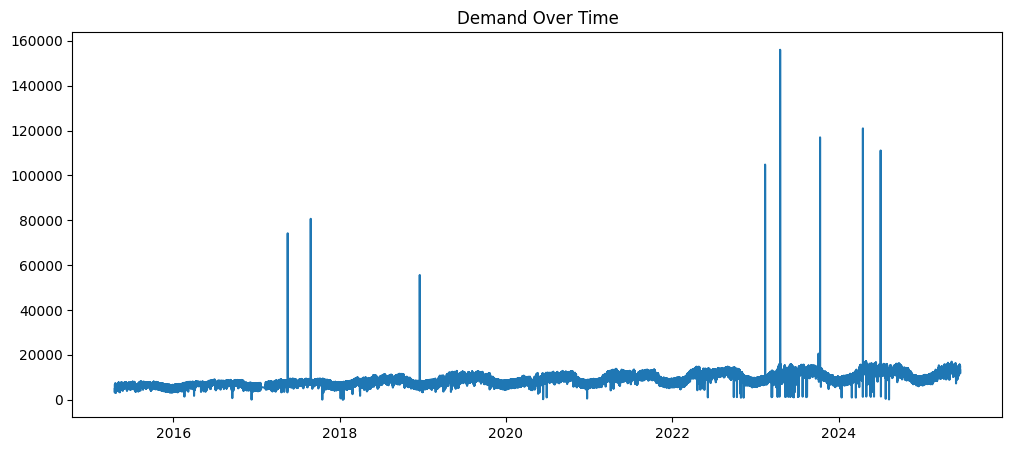

In [19]:

plt.figure(figsize=(12,5))
plt.plot(power['datetime'],power['demand_mw'])
plt.title("Demand Over Time")
plt.show()

Text(0.5, 1.0, 'Demand distribution')

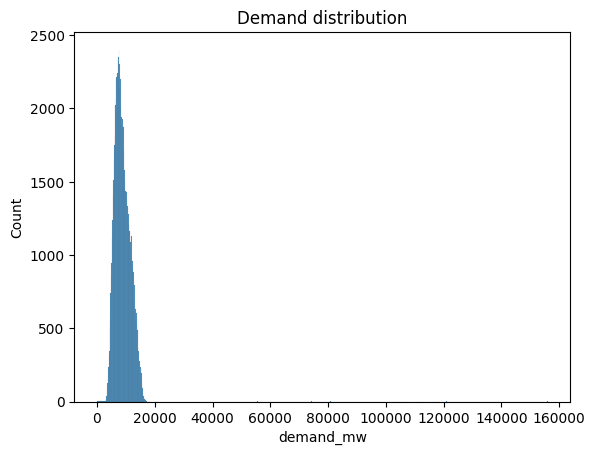

In [20]:

sns.histplot(power['demand_mw'],bins = 1000)
plt.title("Demand distribution")

In [21]:
%%capture
sns.boxplot(x=power['demand_mw'])
plt.title("Outliers in Demand")
plt.show()

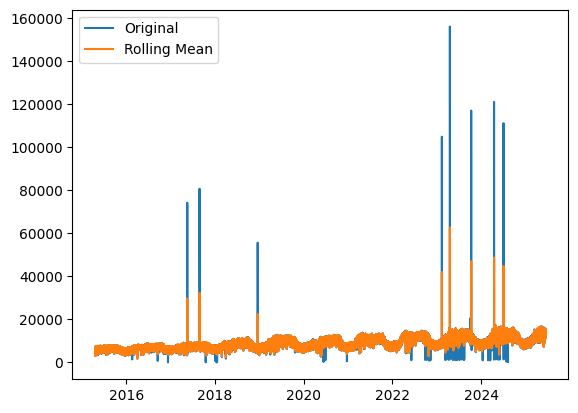

In [22]:
power['rolling_mean'] = power['demand_mw'].rolling(window=3).mean()
plt.plot(power['datetime'], power['demand_mw'], label='Original')
plt.plot(power['datetime'], power['rolling_mean'], label='Rolling Mean')
plt.legend()
plt.show()

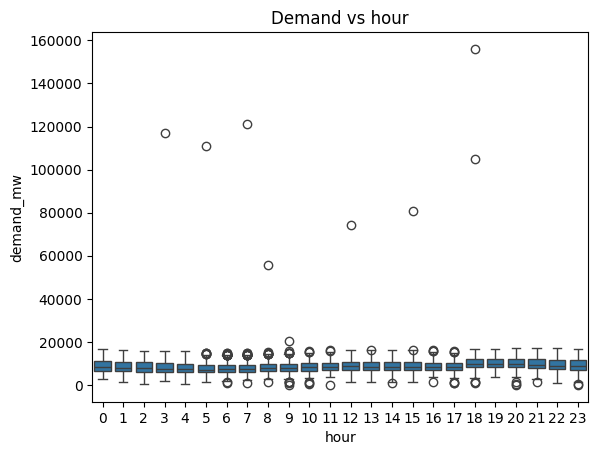

In [23]:
power_eda = power.copy()
power_eda['hour'] = power_eda['datetime'].dt.hour

sns.boxplot(x=power_eda['hour'], y=power_eda['demand_mw'])
plt.title("Demand vs hour")
plt.show()

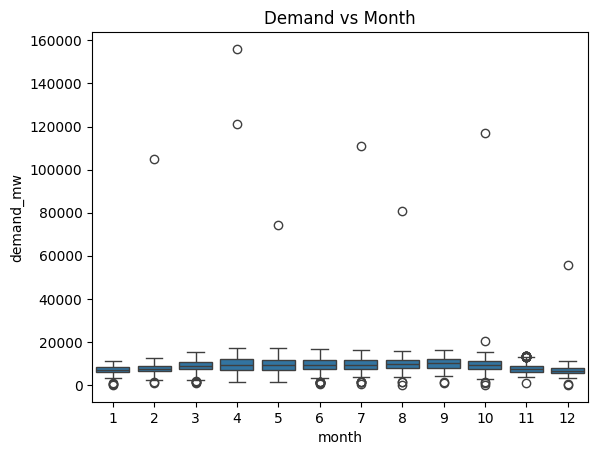

In [24]:
power_eda['month'] = power_eda['datetime'].dt.month

sns.boxplot(x=power_eda['month'], y=power_eda['demand_mw'])
plt.title("Demand vs Month")
plt.show()

In [25]:
corr=power.corr(numeric_only=True)
print(corr)

                      generation_mw  demand_mw  load_shedding       gas  \
generation_mw              1.000000   0.008202       0.002106  0.004387   
demand_mw                  0.008202   1.000000       0.371810  0.487260   
load_shedding              0.002106   0.371810       1.000000  0.073729   
gas                        0.004387   0.487260       0.073729  1.000000   
liquid_fuel                0.000026   0.006813       0.001034  0.000268   
coal                       0.007678   0.629845       0.222747  0.137136   
hydro                     -0.002156   0.074324       0.023215  0.015223   
solar                      0.000597   0.218494       0.125556 -0.029163   
wind                       0.032857   0.021176       0.000730 -0.016210   
india_bheramara_hvdc       0.005536   0.455453       0.110832  0.280770   
india_tripura              0.004738   0.442377       0.112467  0.431826   
india_adani                0.640194   0.634139       0.215394  0.389445   
nepal                    

In [26]:
%%capture
plt.figure(figsize=(14,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

Data Cleaning

In [27]:
df_p = power.copy()

# Convert to datetime for proper time-based operations
df_p['datetime'] = pd.to_datetime(df_p['datetime'])

# Keep only hourly data and remove duplicate timestamps
df_p = df_p[df_p['datetime'].dt.minute == 0].drop_duplicates('datetime')

# Set datetime as index and sort chronologically
df_p.set_index('datetime', inplace=True)
df_p = df_p.sort_index()

# Create continuous hourly timeline to handle missing timestamps
full_range = pd.date_range(start=df_p.index.min(), end=df_p.index.max(), freq='h')
df_p = df_p.reindex(full_range)

# Fill missing values using forward-fill only (no bidirectional interpolation = no future data leakage)
df_p['demand_mw'] = df_p['demand_mw'].ffill()
df_p['generation_mw'] = df_p['generation_mw'].ffill()

# Final fallback for any remaining missing values (forward-fill only)
df_p = df_p.ffill()

df_p['remarks'] = df_p['remarks'].fillna('Normal')

weather = pd.read_csv('weather_data.csv')

In [28]:
weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01T00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01T01:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01T02:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01T03:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01T04:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [29]:
weather['time']

0         2014-01-01T00:00
1         2014-01-01T01:00
2         2014-01-01T02:00
3         2014-01-01T03:00
4         2014-01-01T04:00
                ...       
107299    2026-03-29T19:00
107300    2026-03-29T20:00
107301    2026-03-29T21:00
107302    2026-03-29T22:00
107303    2026-03-29T23:00
Name: time, Length: 107304, dtype: str

In [30]:
weather.columns = (
    weather.columns
    .str.strip()
    .str.replace(r'[°%()]', '', regex=True)
    .str.replace(r'\s+', '_', regex=True)
    .str.lower()
)

In [31]:
# Convert weather time column to datetime and remove duplicates
weather['time'] = pd.to_datetime(weather['time'])
weather = weather.drop_duplicates('time').set_index('time')
w_df = weather.copy()

# Merge power + weather data on time index
df_merged = df_p.join(w_df, how='left')

# Fill missing values with forward-fill only (no bidirectional interpolation)
# This prevents test data (future) from influencing train data (past) during imputation
num_cols = df_merged.select_dtypes(include=[np.number]).columns
df_merged[num_cols] = df_merged[num_cols].ffill()

In [32]:
#Economic Data Processing 

# Extract year-wise columns and reshape 
year_cols = [c for c in economic.columns if c.isdigit()]
eco_long = economic.melt(id_vars=['Indicator Name'], value_vars=year_cols,
                         var_name='Year', value_name='Val')

eco_pivot = eco_long.pivot_table(index='Year', columns='Indicator Name',
                                values='Val').reset_index()

# Align year format for merging
eco_pivot['Year'] = eco_pivot['Year'].astype(int)
df_merged['Year'] = df_merged.index.year


# Select only relevant economic indicators
keep_eco = [
    'GDP (current US$)',
    'Urban population',
    'Energy use (kg of oil equivalent per $1,000 GDP (constant 2021 PPP))',
    'Manufacturing, value added (% of GDP)',
    'Electricity production from natural gas sources (% of total)',
    'Consumer price index (2010 = 100)'
]

available_eco = [c for c in keep_eco if c in eco_pivot.columns]
eco_pivot = eco_pivot[['Year'] + available_eco]

# Merge economic (yearly) data with hourly dataset
df_final = pd.merge(df_merged.reset_index(), eco_pivot, on='Year', how='left')

# Restore datetime index after merge
if 'datetime' not in df_final.columns and 'index' in df_final.columns:
    df_final.rename(columns={'index': 'datetime'}, inplace=True)

df_final.set_index('datetime', inplace=True)
df_final = df_final.ffill()

In [33]:
# Lag Features 

# Demand lags (important for short-term forecasting)
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    df_final[f'demand_lag_{lag}h'] = df_final['demand_mw'].shift(lag)



SUPPLY_COLS = ['generation_mw', 'gas', 'coal', 'hydro', 'solar', 'wind', 'load_shedding']
available_cols = [c for c in SUPPLY_COLS if c in df_final.columns]

for col in available_cols:
    df_final[f'{col}_lag_1h'] = df_final[col].shift(1)
    df_final[f'{col}_lag_24h'] = df_final[col].shift(24)
    df_final[f'{col}_lag_168h'] = df_final[col].shift(168)

# Drop original supply columns to avoid leakage
df_final.drop(columns=available_cols, inplace=True)


# Rolling Statistics (trend + smoothing) 

demand_shifted = df_final['demand_mw'].shift(1)  # only past data

df_final['rolling_mean_3'] = demand_shifted.rolling(3).mean()
df_final['rolling_mean_24'] = demand_shifted.rolling(24).mean()
df_final['rolling_std_24'] = demand_shifted.rolling(24).std()
df_final['rolling_mean_168'] = demand_shifted.rolling(168).mean()  # weekly trend


#  Time-based Features 
df_final['day_of_week'] = df_final.index.dayofweek
df_final['is_weekend'] = df_final['day_of_week'].isin([5, 6]).astype(int)

# Cyclical encoding to capture periodic patterns
df_final['hour_sin'] = np.sin(2 * np.pi * df_final.index.hour / 24)
df_final['hour_cos'] = np.cos(2 * np.pi * df_final.index.hour / 24)

df_final['dow_sin'] = np.sin(2 * np.pi * df_final.index.dayofweek / 7)
df_final['dow_cos'] = np.cos(2 * np.pi * df_final.index.dayofweek / 7)

df_final['month_sin'] = np.sin(2 * np.pi * df_final.index.month / 12)
df_final['month_cos'] = np.cos(2 * np.pi * df_final.index.month / 12)

In [34]:

df_final['hour'] = df_final.index.hour
df_final['dayofweek'] = df_final.index.dayofweek

df_final['target'] = df_final['demand_mw'].shift(-1) # Goal: Predict next hour

# Remove rows with NaNs from shifting
df_model = df_final.dropna(subset=['target'])

print("Pipeline Success!")
print(f"Final Dataset Shape: {df_model.shape}")
df_model.head()

Pipeline Success!
Final Dataset Shape: (89100, 67)


,demand_mw,liquid_fuel,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,rolling_mean,temperature_2m_c,relative_humidity_2m_,...,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,hour,dayofweek,target
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,0.0,0.0,0.0,NaN,NaN,Normal,NaN,25.7,87,...,1,0.000000,1.000000,-0.781831,0.62349,0.866025,-0.5,0,6,3612.0
2015-04-19 01:00:00,3612.0,0.0,0.0,0.0,NaN,NaN,Normal,NaN,25.3,88,...,1,0.258819,0.965926,-0.781831,0.62349,0.866025,-0.5,1,6,3727.0
2015-04-19 02:00:00,3727.0,0.0,0.0,0.0,NaN,NaN,Normal,4053.333333,24.9,90,...,1,0.500000,0.866025,-0.781831,0.62349,0.866025,-0.5,2,6,3632.0
2015-04-19 03:00:00,3632.0,0.0,0.0,0.0,NaN,NaN,Normal,3657.000000,25.0,90,...,1,0.707107,0.707107,-0.781831,0.62349,0.866025,-0.5,3,6,3641.0
2015-04-19 04:00:00,3641.0,0.0,0.0,0.0,NaN,NaN,Normal,3666.666667,25.2,91,...,1,0.866025,0.500000,-0.781831,0.62349,0.866025,-0.5,4,6,3283.0


In [35]:
df_model.isna().sum().sort_values(ascending=False).head(10)

nepal              83946
india_adani        82056
wind_lag_168h      71334
wind_lag_24h       71190
wind_lag_1h        71167
solar_lag_168h     21414
solar_lag_24h      21270
solar_lag_1h       21247
coal_lag_168h        168
demand_lag_168h      168
dtype: int64

In [36]:
df_model.shape

(89100, 67)

In [37]:
df_model = df_model.dropna(axis=1 , how ='all')

In [38]:
df_model.isna().sum().sort_values(ascending=False).head(10)

nepal              83946
india_adani        82056
wind_lag_168h      71334
wind_lag_24h       71190
wind_lag_1h        71167
solar_lag_168h     21414
solar_lag_24h      21270
solar_lag_1h       21247
coal_lag_168h        168
demand_lag_168h      168
dtype: int64

In [39]:
df_model = df_model.ffill()

In [40]:
df_model.isna().sum().sort_values(ascending=False).head(10)

nepal              83946
india_adani        82056
wind_lag_168h      71334
wind_lag_24h       71190
wind_lag_1h        71167
solar_lag_168h     21414
solar_lag_24h      21270
solar_lag_1h       21247
coal_lag_168h        168
demand_lag_168h      168
dtype: int64

In [41]:
df_model=df_model.dropna(subset=['target'])

In [42]:
df_model.isna().sum().sort_values(ascending=False).head(10)

nepal              83946
india_adani        82056
wind_lag_168h      71334
wind_lag_24h       71190
wind_lag_1h        71167
solar_lag_168h     21414
solar_lag_24h      21270
solar_lag_1h       21247
coal_lag_168h        168
demand_lag_168h      168
dtype: int64

In [43]:
df_model.index.min(),df_model.index.max()

(Timestamp('2015-04-19 00:00:00'), Timestamp('2025-06-17 11:00:00'))

Train Test Split

In [44]:
print(df_model.shape)

(89100, 67)


In [45]:
print(df_model.index.min(),df_model.index.max())

2015-04-19 00:00:00 2025-06-17 11:00:00


In [46]:
print(df_final.columns)

Index(['demand_mw', 'liquid_fuel', 'india_bheramara_hvdc', 'india_tripura',
       'india_adani', 'nepal', 'remarks', 'rolling_mean', 'temperature_2m_c',
       'relative_humidity_2m_', 'apparent_temperature_c', 'precipitation_mm',
       'dew_point_2m_c', 'soil_temperature_0_to_7cm_c', 'wind_direction_10m_',
       'cloud_cover_', 'sunshine_duration_s', 'Year', 'GDP (current US$)',
       'Urban population', 'Manufacturing, value added (% of GDP)',
       'Electricity production from natural gas sources (% of total)',
       'Consumer price index (2010 = 100)', 'demand_lag_1h', 'demand_lag_2h',
       'demand_lag_3h', 'demand_lag_6h', 'demand_lag_12h', 'demand_lag_24h',
       'demand_lag_48h', 'demand_lag_168h', 'generation_mw_lag_1h',
       'generation_mw_lag_24h', 'generation_mw_lag_168h', 'gas_lag_1h',
       'gas_lag_24h', 'gas_lag_168h', 'coal_lag_1h', 'coal_lag_24h',
       'coal_lag_168h', 'hydro_lag_1h', 'hydro_lag_24h', 'hydro_lag_168h',
       'solar_lag_1h', 'solar_lag_24

In [47]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error



#Sort dataframe by index and keep only rows where target is available
df_final = df_final.sort_index()
df_model_full = df_final[df_final['target'].notna()].copy()

#Split into train and test
train_data = df_model_full[df_model_full.index < '2024'].copy()
test_data = df_model_full[df_model_full.index >= '2024'].copy()

print(f"Train data shape before features: {train_data.shape}")
print(f"Test data shape before features: {test_data.shape}")
print(f"Train data range: {train_data.index.min()} to {train_data.index.max()}")
print(f"Test data range: {test_data.index.min()} to {test_data.index.max()}")

#  Define feature engineering function (no leakage)
def create_features(df):
    """Create features on isolated data - prevents data leakage"""
    df = df.copy()
    
    # Demand lags (important for short-term forecasting)
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        df[f'demand_lag_{lag}h'] = df['demand_mw'].shift(lag)
    
    # Supply lags
    SUPPLY_COLS = ['generation_mw', 'gas', 'coal', 'hydro', 'solar', 'wind', 'load_shedding']
    available_cols = [c for c in SUPPLY_COLS if c in df.columns]
    
    for col in available_cols:
        df[f'{col}_lag_1h'] = df[col].shift(1)
        df[f'{col}_lag_24h'] = df[col].shift(24)
        df[f'{col}_lag_168h'] = df[col].shift(168)
    
    # Drop original supply columns to avoid leakage
    df = df.drop(columns=available_cols, errors='ignore')
    
    # Rolling Statistics (computed on local data only)
    demand_shifted = df['demand_mw'].shift(1)
    df['rolling_mean_3'] = demand_shifted.rolling(3).mean()
    df['rolling_mean_24'] = demand_shifted.rolling(24).mean()
    df['rolling_std_24'] = demand_shifted.rolling(24).std()
    df['rolling_mean_168'] = demand_shifted.rolling(168).mean()
    
    # Time-based Features
    df['day_of_week'] = df.index.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
    
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    
    return df

# Step 4: Create features SEPARATELY on each split (no data leakage)
print("\nCreating features on train data...")
train_data = create_features(train_data)
print("Creating features on test data...")
test_data = create_features(test_data)

print(f"\nTrain data shape after features: {train_data.shape}")
print(f"Test data shape after features: {test_data.shape}")

# Step 5: Extract X and y (after feature creation)
X_train = train_data.drop(columns=['target', 'demand_mw'])
y_train = train_data['target']

X_test = test_data.drop(columns=['target', 'demand_mw'])
y_test = test_data['target']

# Step 6: Handle NaNs - keep rows even if they have some NaN in features
# The imputer will handle them. Only drop if target is NaN or all features are NaN
mask_train = y_train.notna() & X_train.notna().any(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = y_test.notna() & X_test.notna().any(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

print(f"\nAfter removing rows with NaN target (but keeping feature NaNs):")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

if X_train.shape[0] == 0:
    raise ValueError("ERROR: Train data is empty!")
if X_test.shape[0] == 0:
    raise ValueError("ERROR: Test data is empty!")

# Step 7: Outlier clipping (fit on train only, apply to both)
Q1_tr, Q3_tr = y_train.quantile([0.25, 0.75])
iqr = Q3_tr - Q1_tr
lo, hi = Q1_tr - 3*iqr, Q3_tr + 3*iqr

y_train_clipped = y_train.clip(lo, hi)
y_test_clipped = y_test.clip(lo, hi)

# Step 8: Drop problematic columns
cols_to_drop = ['india_adani', 'nepal']
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

# Step 9: Setup preprocessing pipeline
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = ['remarks'] if 'remarks' in X_train.columns else []

# Numerical pipeline - SimpleImputer will handle remaining NaNs
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
if cat_cols:
    cat_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])
else:
    preprocessor = ColumnTransformer(transformers=[
        ("num", num_pipeline, num_cols)
    ])

# Step 10: Train Random Forest model
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

print("\nTraining Random Forest model...")
pipeline.fit(X_train, y_train_clipped)

y_pred = pipeline.predict(X_test)
mape = mean_absolute_percentage_error(y_test_clipped, y_pred)

print("="*70)
print(f"Random Forest MAPE: {mape:.6f} ({mape*100:.4f}%)")
print("="*70)
print(f"\nModel Performance:")
print(f"  Train samples: {X_train.shape[0]:,}")
print(f"  Test samples: {X_test.shape[0]:,}")
print(f"  Features: {X_train.shape[1]}")


Train data shape before features: (76296, 67)
Test data shape before features: (12804, 67)
Train data range: 2015-04-19 00:00:00 to 2023-12-31 23:00:00
Test data range: 2024-01-01 00:00:00 to 2025-06-17 11:00:00

Creating features on train data...
Creating features on test data...

Train data shape after features: (76296, 67)
Test data shape after features: (12804, 67)

After removing rows with NaN target (but keeping feature NaNs):
X_train shape: (76296, 65), y_train shape: (76296,)
X_test shape: (12804, 65), y_test shape: (12804,)

Training Random Forest model...
Random Forest MAPE: 0.057204 (5.7204%)

Model Performance:
  Train samples: 76,296
  Test samples: 12,804
  Features: 63


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Final pipeline - Linear Regression
pipeline_linearregression = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

print("Training Linear Regression model...")
pipeline_linearregression.fit(X_train, y_train_clipped)
y_pred_lr = pipeline_linearregression.predict(X_test)

mape_lr = mean_absolute_percentage_error(y_test_clipped, y_pred_lr)

print("="*70)
print(f"Linear Regression MAPE: {mape_lr:.6f} ({mape_lr*100:.4f}%)")
print("="*70)


Training Linear Regression model...
Linear Regression MAPE: 0.087108 (8.7108%)


In [49]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# Final pipeline - XGBoost
pipeline_xgb = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        verbosity=0
    ))
])

print("Training XGBoost model...")
pipeline_xgb.fit(X_train, y_train_clipped)
y_pred_xgb = pipeline_xgb.predict(X_test)

mape_xgb = mean_absolute_percentage_error(y_test_clipped, y_pred_xgb)

print("="*70)
print(f"XGBoost MAPE: {mape_xgb:.6f} ({mape_xgb*100:.4f}%)")
print("="*70)


Training XGBoost model...
XGBoost MAPE: 0.049971 (4.9971%)


In [50]:
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor

# Final pipeline - LightGBM
pipeline_lgbm = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=-1,
        random_state=42,
        verbose=-1
    ))
])

print("Training LightGBM model...")
pipeline_lgbm.fit(X_train, y_train_clipped)
y_pred_lgbm = pipeline_lgbm.predict(X_test)

mape_lgbm = mean_absolute_percentage_error(y_test_clipped, y_pred_lgbm)

print("="*70)
print(f"LightGBM MAPE: {mape_lgbm:.6f} ({mape_lgbm*100:.4f}%)")
print("="*70)


Training LightGBM model...
LightGBM MAPE: 0.048075 (4.8075%)


c:\Users\abhis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [51]:
from sklearn import set_config
set_config(display='diagram')
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [52]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [-1, 10, 20, 30],
    "model__num_leaves": [20, 31, 50, 70],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

# Create new pipeline for hyperparameter tuning
pipeline_lgbm_tuning = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LGBMRegressor(random_state=42, verbose=-1))
])

tscv = TimeSeriesSplit(n_splits=3)
random_search = RandomizedSearchCV(
    pipeline_lgbm_tuning,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,  # Time series cross-validation (no data leakage)
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Running hyperparameter tuning with TimeSeriesSplit...")
random_search.fit(X_train, y_train_clipped)

best_model = random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

mape_tuned = mean_absolute_percentage_error(y_test_clipped, y_pred_tuned)

print("\n" + "="*70)
print("Hyperparameter Tuning Results:")
print("="*70)
print(f"Best Params: {random_search.best_params_}")
print(f"Best CV MAPE: {abs(random_search.best_score_):.6f}")
print(f"Test MAPE: {mape_tuned:.6f} ({mape_tuned*100:.4f}%)")
print("="*70)


Running hyperparameter tuning with TimeSeriesSplit...
Fitting 3 folds for each of 20 candidates, totalling 60 fits



Hyperparameter Tuning Results:
Best Params: {'model__subsample': 0.7, 'model__num_leaves': 31, 'model__n_estimators': 100, 'model__max_depth': 20, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
Best CV MAPE: 0.077999
Test MAPE: 0.048889 (4.8889%)


c:\Users\abhis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [53]:
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred)

print("Best Params:", random_search.best_params_)
print("Tuned MAPE:", mape)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'model__subsample': 0.7, 'model__num_leaves': 31, 'model__n_estimators': 200, 'model__max_depth': 30, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Tuned MAPE: 0.05581856167339671


c:\Users\abhis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
